In [81]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
import shap

In [ ]:
all_tornados = pd.read_csv('data/1950-2021_actual_tornadoes.csv')

In [ ]:
all_tornados

In [ ]:
sel_states = ['IL', 'IN', 'IA', 'MI', 'MO']
Midwest_Tornadoes = all_tornados[all_tornados['st'].isin(sel_states)]
Midwest_Tornadoes.set_index(pd.to_datetime(Midwest_Tornadoes['date']), inplace = True)
Midwest_tor_count = Midwest_Tornadoes.resample('MS').size()


In [ ]:
EPNA_data = pd.read_csv('data/EPNA_1951_2025')
EPNA_data.rename(columns = {'Date': 'date'}, inplace = True)
EPNA_data['date'] = pd.to_datetime(EPNA_data['date'])
EPNA_data.set_index('date', inplace = True)

Mw_Tor_Tele = pd.merge(left = Midwest_tor_count.rename('monthly_count'), right = EPNA_data, on = 'date', how = 'inner')

In [ ]:
Mw_Tor_Tele

In [ ]:
# Checking for missing values

Mw_Tor_Tele.isna().sum()

In [ ]:
# taking a look at the distribution of counts for each feature

training_features = ['ENSO', 'PDO', 'NAO', 'AO']

for feature in training_features:
    Mw_Tor_Tele.groupby(feature)['monthly_count'].median().plot()
    plt.ylabel('Monthly count per feature')
    plt.title(feature)
    plt.show()

In [ ]:
# splitting the data into target features and training features.

Y = Mw_Tor_Tele['monthly_count']
X = Mw_Tor_Tele.drop(['monthly_count'], axis = 1)

In [ ]:
# conducted a cv grid search to find the optimal settings.
# it ended up performing worse than the default settings.

param_grid = {
 "max_depth": [10, 25, 50, 100],
 "learning_rate": [0.01, 0.1, 0.5, 0.7],
 "min_samples_leaf": [1,2,3,4,5],
 "n_estimators": [25, 50, 100, 200, 400]}

grid = GridSearchCV(GradientBoostingRegressor(), param_grid=param_grid, cv = 7)



In [ ]:
grid.fit(X,Y)

In [ ]:
grid.best_params_

{'learning_rate': 0.01,
 'max_depth': 100,
 'min_samples_leaf': 5,
 'n_estimators': 25}

In [ ]:
grid.cv_results_

In [ ]:
# Splitting the data into training sets and test sets

Y = Mw_Tor_Tele['monthly_count']
X = Mw_Tor_Tele.drop('monthly_count', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25 )

In [ ]:
# Training a Gradient Boosting Regressor with parameters 
# determined by a CV grid search.

gbr_model_opt = GradientBoostingRegressor(learning_rate = 0.1,
                                      max_depth = 100,
                                      min_samples_leaf = 5,
                                      n_estimators = 25)

gbr_model_opt.fit(X_train, y_train)
gbr_predicted_opt = gbr_model_opt.predict(X_test)

# Computing model performance scores
gbr_opt_R2 = r2_score(y_test, gbr_predicted_opt)
gbr_opt_rmse = root_mean_squared_error(y_test, gbr_predicted_opt)

print("R2 Score the Gradient Boosting Regression is ", gbr_opt_R2)
print("RMSE Score the Gradient Boosting Regression is ", gbr_opt_rmse)

# Computing a cross val to affirm the above results
opt_cross_scores = cross_val_score(gbr_model_opt, X, Y, cv = 7, scoring = 'r2')

print('\n')
print("Using a 7-fold cross-validation we see R2 scores of:")
print(opt_cross_scores)

print('With a mean score of:')
print(opt_cross_scores.mean())




Text(22, 90, 'Correlation Coefficient 0.025')

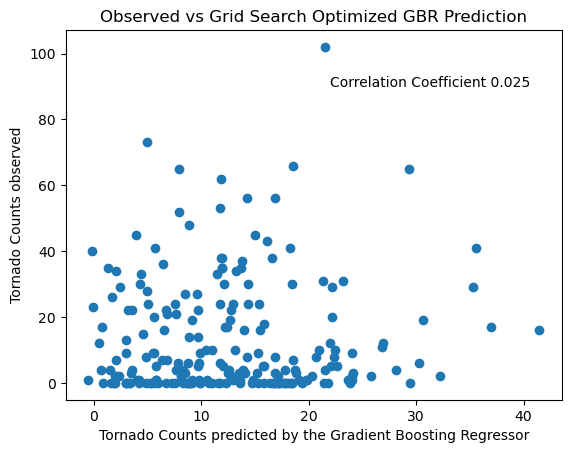

In [78]:
coco = pearsonr(gbr_predicted_opt, y_test)
plt.scatter(gbr_predicted_opt, y_test)
plt.title('Observed vs Grid Search Optimized GBR Prediction')
plt.xlabel('Tornado Counts predicted by the Gradient Boosting Regressor')
plt.ylabel('Tornado Counts observed')

plt.text(x = 22, y = 90, s = "Correlation Coefficient " + str(np.round(coco.statistic, 3)))

In [ ]:
# Training a Gradient Boosting Regressor with default
# values.

gbr_model = GradientBoostingRegressor()
gbr_model.fit(X_train, y_train)
gbr_model.score(X_test, y_test)

gbr_model.fit(X_train, y_train)
gbr_predicted = gbr_model.predict(X_test)

# Computing model performance scores
gbr_R2 = r2_score(y_test, gbr_predicted)
gbr_rmse = root_mean_squared_error(y_test, gbr_predicted)

print("R2 Score the Gradient Boosting Regression is ", gbr_R2)
print("RMSE Score the Gradient Boosting Regression is ", gbr_rmse)

# Computing a cross val to affirm the above results
cross_scores = cross_val_score(gbr_model, X, Y, cv = 7, scoring = 'r2')

print('\n')
print("Using a 7-fold cross-validation we see R2 scores of:")
print(cross_scores)
print('With a mean score of:')
print(cross_scores.mean())

Text(45, 90, 'Correlation Coefficient 0.445')

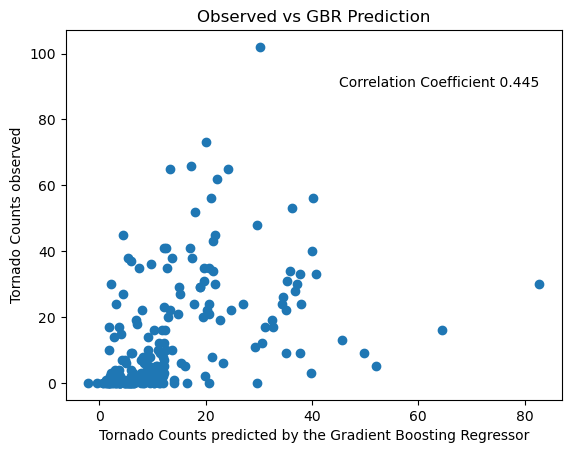

In [80]:
coco = pearsonr(gbr_predicted, y_test)

plt.scatter(gbr_predicted, y_test)
plt.title('Observed vs GBR Prediction')
plt.xlabel('Tornado Counts predicted by the Gradient Boosting Regressor')
plt.ylabel('Tornado Counts observed')

plt.text(x = 45, y = 90, s = "Correlation Coefficient " + str(np.round(coco.statistic, 3)))

In [ ]:
vec = CountVectorizer()

months = vec.fit_transform(Mw_Tor_Tele.index.month_name())
months = pd.DataFrame(months.toarray(), columns=vec.get_feature_names_out())
months.set_index(Mw_Tor_Tele.index, inplace = True)
Mw_Tor_Tele = pd.concat([Mw_Tor_Tele, months], axis = 1)

In [ ]:
Y = Mw_Tor_Tele['monthly_count']
X = Mw_Tor_Tele.drop('monthly_count', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25 )

In [ ]:
# Training a Gradient Boosting Regressor with One-Hot encoding
# in the dataset.

gbr_model_OH = GradientBoostingRegressor()
gbr_model_OH.fit(X_train, y_train)
gbr_model_OH.score(X_test, y_test)

gbr_model_OH.fit(X_train, y_train)
gbr_predicted_OH = gbr_model_OH.predict(X_test)

# Computing model performance scores
gbr_R2 = r2_score(y_test, gbr_predicted_OH)
gbr_rmse = root_mean_squared_error(y_test, gbr_predicted_OH)

print("R2 Score for the Gradient Boosting Regression with One Hot encoding of the months is ", gbr_R2)
print("RMSE Score forthe Gradient Boosting Regression with One Hot encoding of the months is ", gbr_rmse)

# Computing a cross val to affirm the above results
cross_scores = cross_val_score(gbr_model_OH, X, Y, cv = 7, scoring = 'r2')

print('\n')
print("Using a 7-fold cross-validation we see R2 scores of:")
print(cross_scores)
print('With a mean score of:')
print(cross_scores.mean())

Text(50, 90, 'Correlation Coefficient 0.44')

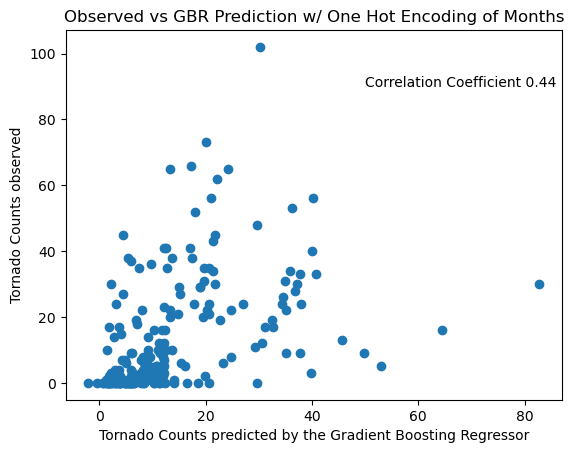

In [75]:
coco = pearsonr(gbr_predicted_OH, y_test)
plt.scatter(gbr_predicted_OH, y_test)
plt.title('Observed vs GBR Prediction w/ One Hot Encoding of Months')
plt.xlabel('Tornado Counts predicted by the Gradient Boosting Regressor')
plt.ylabel('Tornado Counts observed')
plt.text(x = 50, y = 90, s = "Correlation Coefficient " + str(np.round(coco.statistic, 3)))

In [62]:
feature_names = gbr_model_OH.feature_names_in_

mdi_importances = pd.Series(
    gbr_model_OH.feature_importances_, index=feature_names
).sort_values(ascending=True)

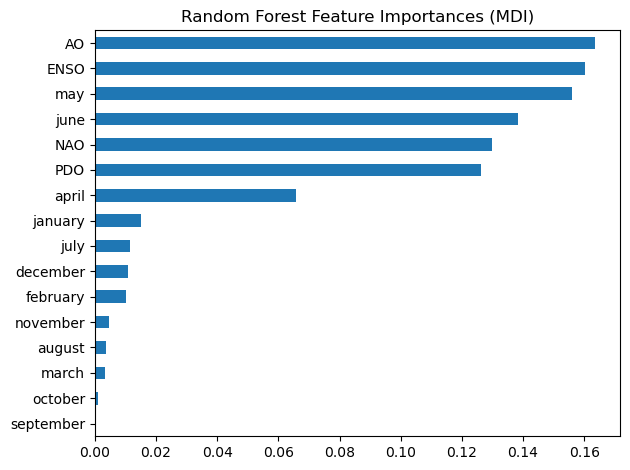

In [63]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

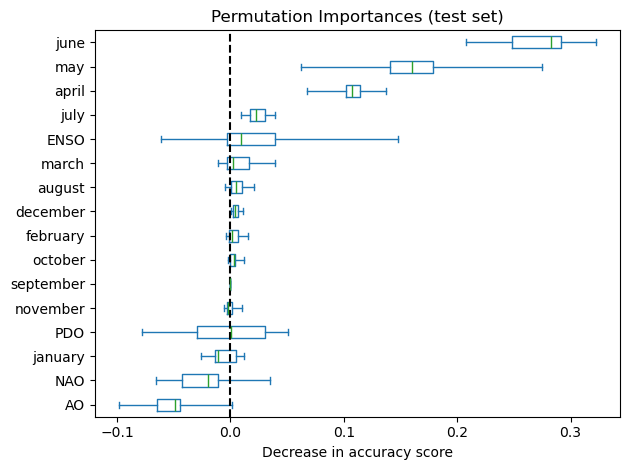

In [64]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    gbr_model_OH, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

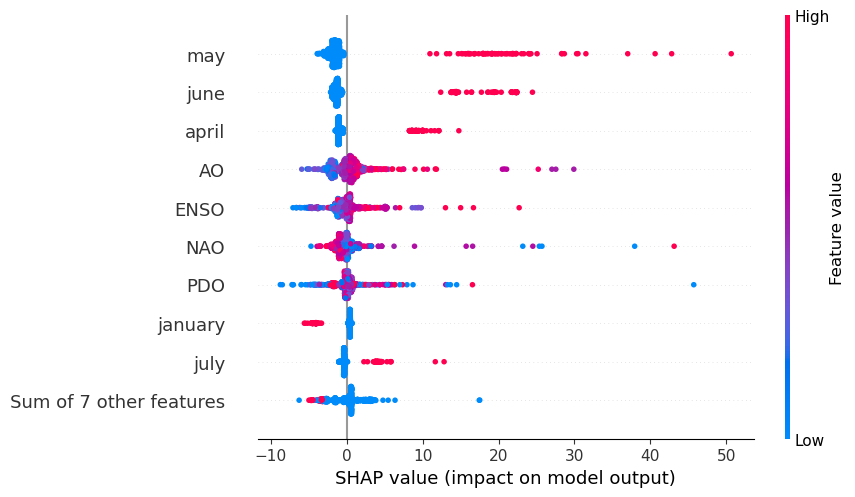

In [85]:
explainer = shap.Explainer(gbr_model_OH)
shap_values = explainer(X)

shap.plots.beeswarm(shap_values)